# Dimensionality Reduction

In this exercise, we will use principal component analysis to perform dimensionality reduction on our dataset. Recall that the `netml` library has mechanisms to extract a wide range of statistics from traffic flows. We will start with those (an N-dimensional feature set), and then use principal component analysis to reduce the dimensionality of the data.

In [1]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP

import pandas as pd

## Load the Packet Capture Files

Load the Log4j and HTTP packet capture files and extract features from the flows. You can feel free to compute features manually, although it will likely be more convenient at this point to use the `netML` library.

In [3]:
from netml.pparser.parser import PCAP

pcap = PCAP(
    'data/log4j.pcap',
    flow_ptks_thres=2,     # drop flows with <2 packets
    verbose=10,
    random_state=42,
)

pcap.pcap2flows()                      # pcap -> flows
pcap.flow2features('IAT', fft=False, header=False)

X = pcap.features                      # numpy array, one row per flow
fids = [f[0] for f in pcap.flows]      # (sip, dip, sport, dport, proto) per row

pcap_file: data/log4j.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
ith_packets: 30000
ith_packets: 40000
ith_packets: 50000
ith_packets: 60000
ith_packets: 70000
ith_packets: 80000
len(flows): 44707
total number of flows: 44707. Num of flows < 2 pkts: 39869, and >=2 pkts: 4838 without timeout splitting.
kept flows: 4766. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (4766, 1)
          col_0
count  4766.000
mean     12.068
std     191.592
min       0.000
25%       0.454
50%       5.075
75%       7.065
max   12889.480
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4766 entries, 0 to 4765
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   4766 non-null   float64
dtypes: float64(1)
memory usage: 37.4 KB
None
0th_flow: len(pkts): 6
1000th_flow: len(pkts): 5
2000th_flow: len(pkts): 5
3000th_flow: len(pkts): 6
4000th_flow: len(pkts): 5
After splitting flows, the number of sub

In [5]:
pcap_http = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10, random_state=42)
pcap_http.pcap2flows()
pcap_http.flow2features('STATS', fft=False, header=False)
S_http = pcap_http.features

pcap_file: data/http.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.
True


In [4]:
print(len(pcap.flows), X.shape)
print(fids[:3])
print(X[:2])

4795 (4795, 5)
[('128.14.134.170', '198.71.247.91', 57468, 80, 6), ('198.71.247.91', '128.14.134.170', 80, 57468, 6), ('92.255.85.37', '198.71.247.91', 36498, 22, 6)]
[[1.15430355e-02 5.00679016e-05 1.27089024e-02 5.04110408e+00
  9.73989964e-02]
 [1.15861893e-02 1.09100342e-03 5.00433397e+00 1.45769835e-01
  0.00000000e+00]]


## Convert the Packet Capture Into Flows

Find the function in `netml` that converts the pcap file into flows. Examing the resulting data structure. What does it contain?

In [9]:
print(type(pcap.flows), len(pcap.flows))

fid, pkts = pcap.flows[0]
print('fid :', fid)
print('pkts:', len(pkts), type(pkts[0]))
print(pkts[0].summary())

<class 'list'> 4795
fid : ('128.14.134.170', '198.71.247.91', 57468, 80, 6)
pkts: 6 <class 'scapy.layers.l2.Ether'>
Ether / IP / TCP 128.14.134.170:57468 > 198.71.247.91:http S


This contains 4795 two-tuples, each holding a 5-tuple flow ID and a list of scapy packets.

## Explore the Flows

How many flows are in each of these pcaps? (Use the `netml` library output to determine the size of each data structure.)

In [10]:
for name in ['log4j', 'http']:
    p = PCAP(f'data/{name}.pcap', flow_ptks_thres=2, verbose=0, random_state=42)
    p.pcap2flows()
    print(name, len(p.flows))

log4j 4795
http 291


## Try Your Data on a Tree-Based Model

You should now have data that can be input into a model with scikit-learn. Import the scikit-learn package (`sklearn`) and a classification model of your choice to test that you can train your model with the above data. 

Hint: The function you want to call is `fit`.

Before applying dimensionality reduction, we can first build on our understanding of classifiers from past notebooks to see which features may be most important. 

Let's try training a model first with a **Decision Tree**, then with a RandomForest classifier, which gives us nice ways of exploring feature importance.

### Decision Tree

Train a decision tree below.

In [ ]:
# Building/finishing up the features
import numpy as np
from netml.pparser.parser import PCAP

def stats_features(path):
    p = PCAP(path, flow_ptks_thres=2, verbose=0, random_state=42)
    p.pcap2flows()
    p.flow2features('STATS', fft=False, header=False)
    return p.features, p.flows

S_log4j, flows_log4j = stats_features('data/log4j.pcap')
S_http,  flows_http  = stats_features('data/http.pcap')

S_all = np.vstack([S_log4j, S_http])
y = np.concatenate([np.ones(len(S_log4j)), np.zeros(len(S_http))])

print(S_log4j.shape, S_http.shape, S_all.shape, y.shape)

(4795, 12) (291, 12) (5086, 12) (5086,)


In [16]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(S_all, y, test_size=0.3, random_state=42, stratify=y)

# Training a Random Forest Classifier
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_tr, y_tr)          # <-- training happens here

DecisionTreeClassifier(max_depth=5, random_state=42)

In [17]:
# Evaluating the classifier
from sklearn.metrics import classification_report
print(classification_report(y_te, clf.predict(X_te)))

              precision    recall  f1-score   support

         0.0       1.00      0.66      0.79        87
         1.0       0.98      1.00      0.99      1439

    accuracy                           0.98      1526
   macro avg       0.99      0.83      0.89      1526
weighted avg       0.98      0.98      0.98      1526



### Visualize the Resulting Model

Below is an example showing how the resulting decision tree can be visualized. We kept the number of features small above to make visualization quick. You may need to install some dependencies (pydotplus, plus the graphviz executable, to get this cell to run.

To install graphviz on a Mac, for example, you can use a tool like Homebrew (e.g., brew install graphviz).

In [28]:
!brew install graphviz

zsh:1: command not found: brew


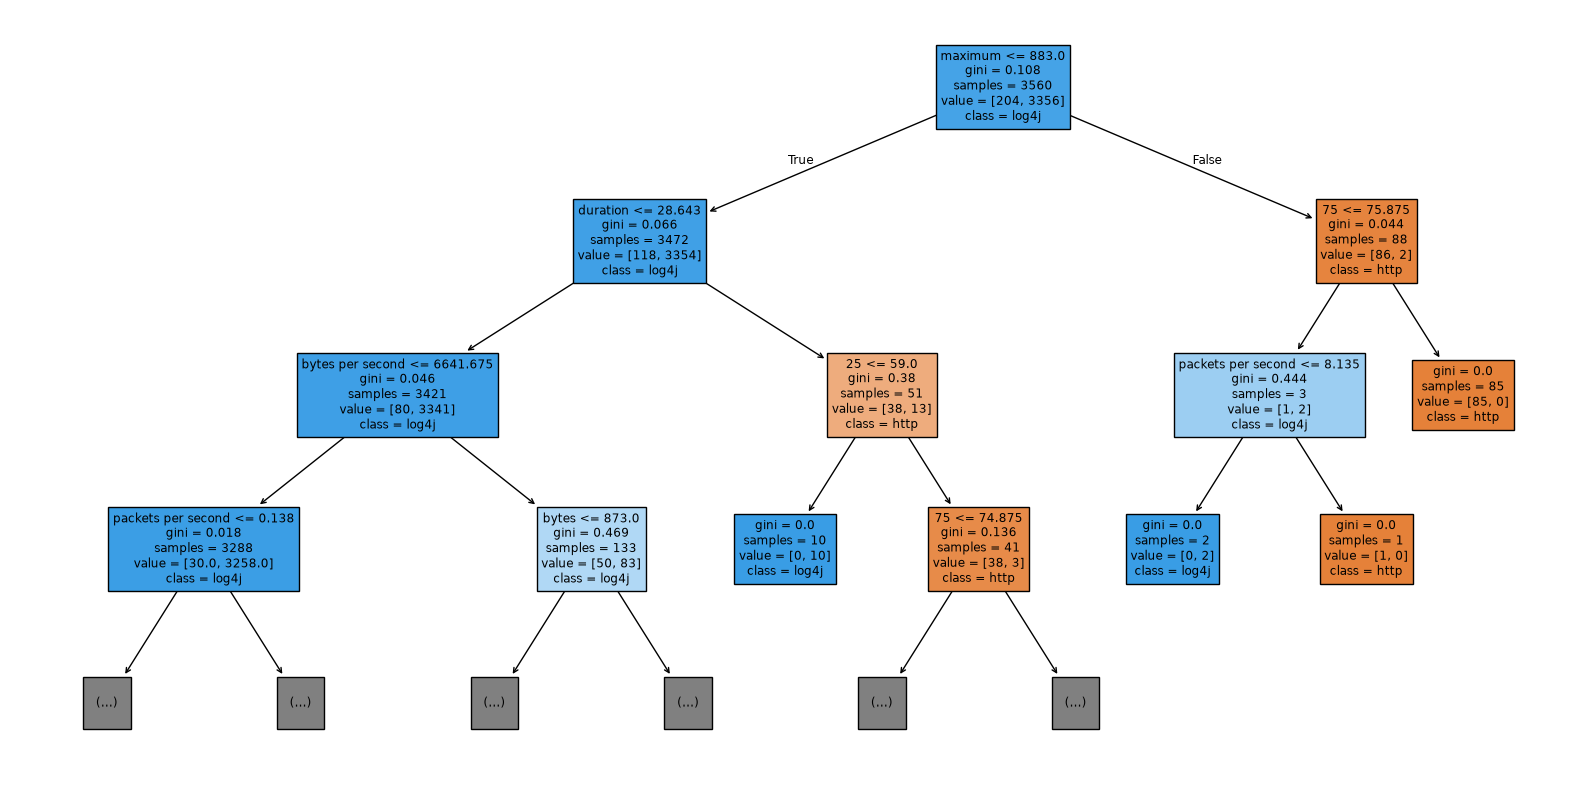

In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=labels, class_names=['http', 'log4j'],
          filled=True, max_depth=3)
plt.show()

### Evaluate the Model

We can look at the accuracy of this simple model using a K-Fold cross validation and accuracy score.

In [ ]:
from sklearn.metrics import accuracy_score

clf.fit(X_tr, y_tr)
print(accuracy_score(y_te, clf.predict(X_te)))


0.9803407601572739
[0.98428291 0.9813176  0.98623402 0.98426745 0.99213373]
0.986 +/- 0.004


In [33]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = DecisionTreeClassifier(max_depth=5, random_state=42)

scores = cross_val_score(clf, S_all, y, cv=cv, scoring='accuracy')
print(scores)
print(f'{scores.mean():.3f} +/- {scores.std():.3f}')

[0.98428291 0.9813176  0.98623402 0.98426745 0.99213373]
0.986 +/- 0.004


## Random Forest Classifiers
Random forest improves on a decision tree classifier using an ensemble learning method called bagging. In a random forest, 

1. many decision trees are trained. Each tree receives a boostrapped sample of observations, and
2. each node only considers a subset of the features when determining the best split.

The balanced mode, which we use below, uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)).

### Train a Random Forest Classifier

Train a random forest classifier using the same approach as you used for the decision tree.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_tr, y_tr)

y_pred = rf.predict(X_te)
print(accuracy_score(y_te, y_pred))
print(confusion_matrix(y_te, y_pred))
print(classification_report(y_te, y_pred))

0.9855832241153342
[[  65   22]
 [   0 1439]]
              precision    recall  f1-score   support

         0.0       1.00      0.75      0.86        87
         1.0       0.98      1.00      0.99      1439

    accuracy                           0.99      1526
   macro avg       0.99      0.87      0.92      1526
weighted avg       0.99      0.99      0.98      1526



In [35]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for m in ['accuracy', 'f1_macro', 'balanced_accuracy']:
    s = cross_val_score(rf, S_all, y, cv=cv, scoring=m)
    print(f'{m:20s} {s.mean():.3f} +/- {s.std():.3f}')

accuracy             0.988 +/- 0.003
f1_macro             0.940 +/- 0.015
balanced_accuracy    0.907 +/- 0.025


In [36]:
for name, imp in sorted(zip(labels, rf.feature_importances_), key=lambda t: -t[1]):
    print(f'{name:22s} {imp:.3f}')

maximum                0.193
bytes                  0.137
median                 0.106
packets                0.097
bytes per second       0.078
standard deviation     0.077
75                     0.076
duration               0.070
packets per second     0.062
minimum                0.055
mean                   0.026
25                     0.022


### Evaluate Your Classifier

Evaluate your random forest classifier using the same evaluation method as for the decision tree.  Does accuracy improve?

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold

y_pred = rf.predict(X_te)

print(accuracy_score(y_te, y_pred))
print(confusion_matrix(y_te, y_pred))
print(classification_report(y_te, y_pred))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, S_all, y, cv=cv, scoring='accuracy')
print(f'{scores.mean():.3f} +/- {scores.std():.3f}')

0.9855832241153342
[[  65   22]
 [   0 1439]]
              precision    recall  f1-score   support

         0.0       1.00      0.75      0.86        87
         1.0       0.98      1.00      0.99      1439

    accuracy                           0.99      1526
   macro avg       0.99      0.87      0.92      1526
weighted avg       0.99      0.99      0.98      1526

0.988 +/- 0.003


In [38]:
# comparing the two models

for name, model in [('decision tree', clf), ('random forest', rf)]:
    s = cross_val_score(model, S_all, y, cv=cv, scoring='accuracy')
    f = cross_val_score(model, S_all, y, cv=cv, scoring='f1_macro')
    print(f'{name:16s} acc {s.mean():.3f} +/- {s.std():.3f}   macro-F1 {f.mean():.3f} +/- {f.std():.3f}')

decision tree    acc 0.986 +/- 0.004   macro-F1 0.927 +/- 0.019
random forest    acc 0.988 +/- 0.003   macro-F1 0.940 +/- 0.015


The accuracy for the random forest does improve, only slightly.

## Feature Importance

One of the powerful aspects of a random forest classifier is that it is easy to plot and understand feature importance. The feature_importances_ data structure maintains these relative feature importance values, which we can plot and visualize.

## Dimensionality Reduction

One way to reduce the dimensionality of a dataset is with a technique called principal components analysis (PCA). PCA is a linear transformation that maps the points into a space where the lower dimensions are orthogonal and also capture the highest variance in the dataset.

So, the first principal component (PC1) is a vector that is oriented in the direction that captures the highest variance in the dataset. You can think of this as the single dimension that has the most information in the dataset. PC2 captures the next highest variance, in the direction that is orthogonal to PC2, and so forth.

There are many applications of PCA, but one application is the visualization of a high-dimension dataset, since PCA is just a transformation of the data that does not inherently lose information. When we only project into the top two dimensions, some information is lost (whatever is in the lower principal compoenents), but we can visualize the data in terms of the two dimensions that capture the most "information" (i.e., variance) in the dataset.

### Understanding Explained Variance

The first principal components will capture msot of the variance. We can look at the explained variance ratio to understand how much variance each of those principal components captures, which will give us a sense of where we might be able to cut off this data, particularly if we look at cumulative explained variance.

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Z = StandardScaler().fit_transform(S_all)
pca = PCA(n_components=2)
XY = pca.fit_transform(Z)

print(pca.explained_variance_ratio_)
print(XY.shape)

[0.4203064  0.18130897]
(5086, 2)


/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.co

/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:611: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


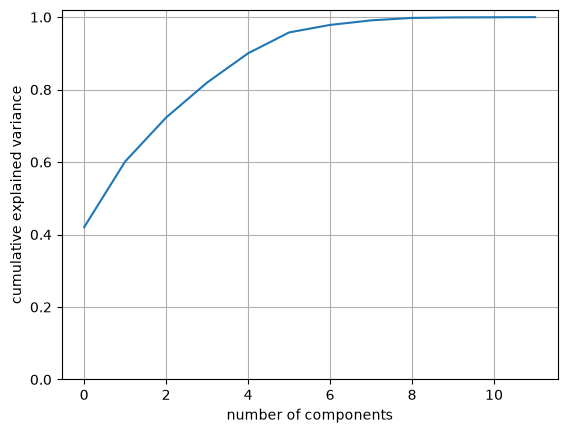

In [42]:
Z = StandardScaler().fit_transform(S_all)

pca = PCA(n_components=12)
pca.fit(Z)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.ylim([0, 1.02])
plt.grid(True)

### Understanding the Top Principal Components

If we look at the top principal component, we can also see that it is a linear combination of our original features, which has a disproportionate "amount" of the 25th percentile of packet size.

In [43]:
pca.components_[0]


array([-0.01748244,  0.02922202,  0.18117736,  0.42935383,  0.25996848,
        0.3719829 ,  0.39026635,  0.37935451,  0.04339694,  0.30182474,
        0.30665191,  0.30410701])

In [44]:
# Sort in descending order
indices = np.argsort(pca.components_[0])[::-1]

# Sort the labels in a corresponding fashion
names = [labels[i] for i in indices]
names

['mean',
 'median',
 '75',
 '25',
 'packets',
 'bytes',
 'maximum',
 'standard deviation',
 'bytes per second',
 'minimum',
 'packets per second',
 'duration']

### Evaluate the Lower Dimension Model

Evaluate the accuracy of the lower dimensionality model trained on the random forest classifier in the same fashion as above. What happens to the accuracy? Why?

What might be a good reason to reduce the dimensionality of the dataset?

In [50]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pca = Pipeline([
    ('scale', StandardScaler()),
    ('pca',   PCA(n_components=3)),
    ('rf',    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
])

for m in ['accuracy', 'f1_macro']:
    s = cross_val_score(rf_pca, S_all, y, cv=cv, scoring=m)
    print(f'{m:12s} {s.mean():.3f} +/- {s.std():.3f}')

accuracy     0.971 +/- 0.002
f1_macro     0.824 +/- 0.019


In [49]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)